# TÉCNICA SUPER RESOLUTION EN EL DATASET

In [ ]:
import os
import glob
import random
import time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import StepLR

# Métricas
from skimage.metrics import peak_signal_noise_ratio as psnr_skimage
from skimage.metrics import structural_similarity as ssim_skimage
import lpips

# Visualización 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Rutas del dataset 
HR_DIR  = Path('dataset/Training')                  
LR_DIR  = Path('dataset/Training_LR_escala2') 

# Hiperparámetros 
IMG_H        = 112
IMG_W        = 92
BATCH_SIZE   = 16     
NUM_EPOCHS   = 100
LR_INIT      = 1e-4
SCHED_STEP   = 30     
SCHED_GAMMA  = 0.5
VAL_SPLIT    = 0.15
WEIGHTS_PATH = 'srcnn_orl_best.pth'

print('\n Configuración cargada.')
print(f'   HR_DIR  existe: {HR_DIR.exists()}')
print(f'   LR_DIR  existe: {LR_DIR.exists()}')

Dispositivo: cpu

 Configuración cargada.
   HR_DIR  existe: True
   LR_DIR  existe: True


In [ ]:
class SRCNN(nn.Module):
    """
    Super-Resolution Convolutional Neural Network.
    Entrada : tensor (B, 1, H, W)  — imagen en escala de grises normalizada [0,1]
    Salida  : tensor (B, 1, H, W)  — imagen HR reconstruida
    """
    def __init__(self):
        super(SRCNN, self).__init__()

        # Extracción de parches y representación
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=9, padding=4  # padding=kernel//2 → mismo tamaño
        )
        # Mapeo no lineal
        self.conv2 = nn.Conv2d(
            in_channels=64, out_channels=32,
            kernel_size=5, padding=2
        )
        # Reconstrucción
        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=1,
            kernel_size=5, padding=2
        )
        self.relu = nn.ReLU(inplace=True)

        # Inicialización de pesos (He)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x


# Verificación de la arquitectura 
model = SRCNN().to(DEVICE)
print(model)

dummy = torch.randn(1, 1, IMG_H, IMG_W).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'\nEntrada : {tuple(dummy.shape)}')
print(f'Salida  : {tuple(out.shape)}')

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

SRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)

Entrada : (1, 1, 112, 92)
Salida  : (1, 1, 112, 92)
Parámetros entrenables: 57,281


In [49]:
class ORLSuperResDataset(Dataset):
    EXTENSIONS = {'.pgm', '.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    def __init__(self, hr_root: Path, lr_root: Path, transform=None):
        self.hr_root   = hr_root
        self.lr_root   = lr_root
        self.transform = transform
        self.pairs     = []
        self._build_pairs()

    def _build_pairs(self):
        """Construye lista de tuplas (lr_path, hr_path)."""
        if not self.hr_root.exists():
            raise FileNotFoundError(f'HR directory not found: {self.hr_root}')
        if not self.lr_root.exists():
            raise FileNotFoundError(f'LR directory not found: {self.lr_root}')

        # Recorrer carpetas de sujetos en HR
        for subject_hr in sorted(self.hr_root.iterdir()):
            if not subject_hr.is_dir():
                continue
            subject_lr = self.lr_root / subject_hr.name
            if not subject_lr.exists():
                print(f'  ⚠ Sujeto LR no encontrado: {subject_lr}')
                continue

            # Emparejar imágenes por nombre de archivo
            for hr_img in sorted(subject_hr.iterdir()):
                if hr_img.suffix.lower() not in self.EXTENSIONS:
                    continue
                # Buscar LR con mismo nombre (puede diferir en extensión)
                lr_img = subject_lr / hr_img.name
                if not lr_img.exists():
                    # Intentar otras extensiones
                    for ext in self.EXTENSIONS:
                        alt = subject_lr / (hr_img.stem + ext)
                        if alt.exists():
                            lr_img = alt
                            break
                    else:
                        print(f'  ⚠ Par LR no encontrado para: {hr_img}')
                        continue
                self.pairs.append((lr_img, hr_img))

        print(f'Pares encontrados: {len(self.pairs)}')

    def _load_gray(self, path: Path) -> np.ndarray:
        """Carga imagen en escala de grises y devuelve array float32 [0,1]."""
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise IOError(f'No se pudo leer: {path}')
        # Asegurar dimensiones correctas
        if img.shape != (IMG_H, IMG_W):
            img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_CUBIC)
        return img.astype(np.float32) / 255.0

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr = self._load_gray(lr_path)  # (H, W) float32
        hr = self._load_gray(hr_path)

        # Agregar dimensión de canal → (1, H, W)
        lr = torch.from_numpy(lr).unsqueeze(0)
        hr = torch.from_numpy(hr).unsqueeze(0)

        return lr, hr

full_dataset = ORLSuperResDataset(HR_DIR, LR_DIR)

# Mostrar muestra
lr_sample, hr_sample = full_dataset[0]
print(f'\nForma tensor LR : {tuple(lr_sample.shape)}  rango [{lr_sample.min():.2f}, {lr_sample.max():.2f}]')
print(f'Forma tensor HR : {tuple(hr_sample.shape)}  rango [{hr_sample.min():.2f}, {hr_sample.max():.2f}]')

Pares encontrados: 360

Forma tensor LR : (1, 112, 92)  rango [0.06, 1.00]
Forma tensor HR : (1, 112, 92)  rango [0.04, 0.92]


In [52]:
n_total = len(full_dataset)
n_val   = max(1, int(n_total * VAL_SPLIT))
n_train = n_total - n_val

train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda')
)
val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda')
)

print(f'Total imágenes : {n_total}')
print(f'Entrenamiento  : {n_train}  ({n_train/n_total*100:.1f}%)')
print(f'Validación     : {n_val}   ({n_val/n_total*100:.1f}%)')
print(f'Batches/época  : {len(train_loader)}')

Total imágenes : 360
Entrenamiento  : 306  (85.0%)
Validación     : 54   (15.0%)
Batches/época  : 20


In [ ]:
# ── Función auxiliar de validación ─────────────────────────────────────────
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for lr_imgs, hr_imgs in loader:
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            outputs = model(lr_imgs)
            outputs = torch.clamp(outputs, 0.0, 1.0)
            loss = criterion(outputs, hr_imgs)
            total_loss += loss.item() * lr_imgs.size(0)
    return total_loss / len(loader.dataset)


# ── Configurar entrenamiento ────────────────────────────────────────────────
model     = SRCNN().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = StepLR(optimizer, step_size=SCHED_STEP, gamma=SCHED_GAMMA)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

print('Iniciando entrenamiento...')
print(f'   Épocas   : {NUM_EPOCHS}')
print(f'   Batch    : {BATCH_SIZE}')
print(f'   LR init  : {LR_INIT}')
print(f'   Scheduler: StepLR(step={SCHED_STEP}, γ={SCHED_GAMMA})')
print('─' * 60)

t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Fase entrenamiento ─────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for lr_imgs, hr_imgs in train_loader:
        lr_imgs = lr_imgs.to(DEVICE)
        hr_imgs = hr_imgs.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(lr_imgs)
        outputs = torch.clamp(outputs, 0.0, 1.0)
        loss = criterion(outputs, hr_imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * lr_imgs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Fase validación ────────────────────────────────────────────────────
    val_loss = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # ── Guardar mejor modelo ───────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : val_loss,
        }, WEIGHTS_PATH)
        saved_tag = ' ✦ guardado'
    else:
        saved_tag = ''

    # ── Log cada 10 épocas ─────────────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        lr_cur  = scheduler.get_last_lr()[0]
        print(f'Época [{epoch:3d}/{NUM_EPOCHS}]  '
              f'train: {train_loss:.6f}  val: {val_loss:.6f}  '
              f'lr: {lr_cur:.2e}  t: {elapsed:.0f}s{saved_tag}')

print('─' * 60)
print(f' Entrenamiento completado en {time.time()-t0:.1f} s')
print(f'   Mejor val loss: {best_val_loss:.6f}  →  {WEIGHTS_PATH}')

🚀 Iniciando entrenamiento...
   Épocas   : 100
   Batch    : 16
   LR init  : 0.0001
   Scheduler: StepLR(step=30, γ=0.5)
────────────────────────────────────────────────────────────
Época [  1/100]  train: 0.050288  val: 0.021926  lr: 1.00e-04  t: 8s ✦ guardado
Época [ 10/100]  train: 0.006220  val: 0.006637  lr: 1.00e-04  t: 74s
Época [ 20/100]  train: 0.005373  val: 0.005236  lr: 1.00e-04  t: 151s ✦ guardado
Época [ 30/100]  train: 0.004969  val: 0.004972  lr: 5.00e-05  t: 225s ✦ guardado
Época [ 40/100]  train: 0.004759  val: 0.004870  lr: 5.00e-05  t: 302s
Época [ 50/100]  train: 0.004626  val: 0.004687  lr: 5.00e-05  t: 374s ✦ guardado
Época [ 60/100]  train: 0.004576  val: 0.004655  lr: 2.50e-05  t: 443s
Época [ 70/100]  train: 0.004516  val: 0.004598  lr: 2.50e-05  t: 519s
Época [ 80/100]  train: 0.004503  val: 0.004545  lr: 2.50e-05  t: 592s
Época [ 90/100]  train: 0.004466  val: 0.004517  lr: 1.25e-05  t: 665s
Época [100/100]  train: 0.004405  val: 0.004563  lr: 1.25e-05  t: 

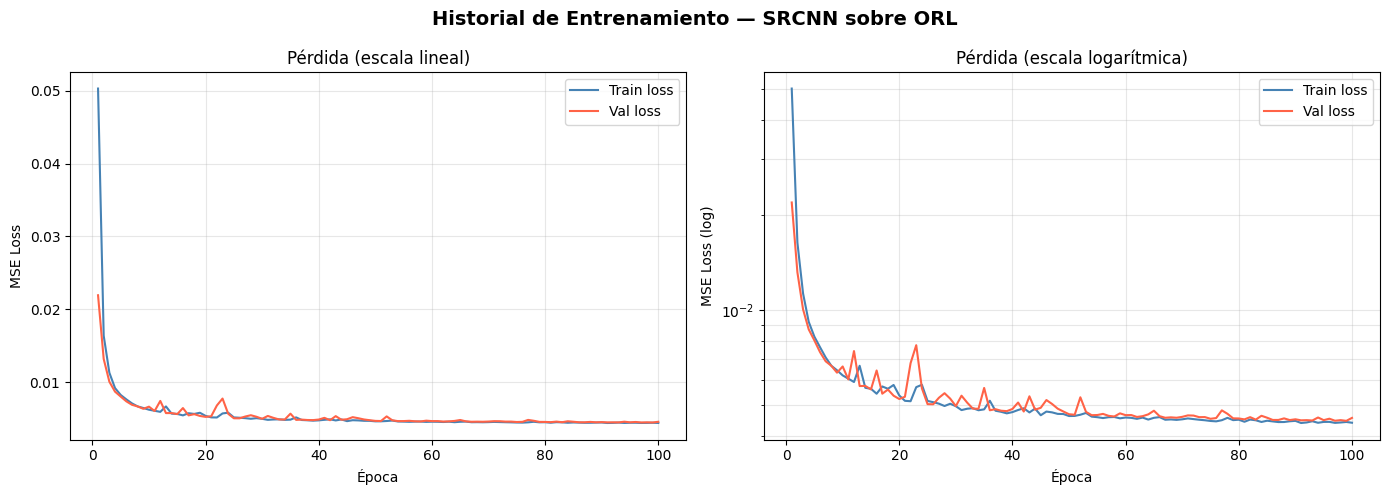

Figura guardada: loss_curves.png


In [54]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Historial de Entrenamiento — SRCNN sobre ORL', fontsize=14, fontweight='bold')

# ── Pérdida en escala lineal ───────────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], label='Train loss', color='steelblue', linewidth=1.5)
axes[0].plot(epochs_range, history['val_loss'],   label='Val loss',   color='tomato',    linewidth=1.5)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Pérdida (escala lineal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Pérdida en escala logarítmica ─────────────────────────────────────────
axes[1].semilogy(epochs_range, history['train_loss'], label='Train loss', color='steelblue', linewidth=1.5)
axes[1].semilogy(epochs_range, history['val_loss'],   label='Val loss',   color='tomato',    linewidth=1.5)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MSE Loss (log)')
axes[1].set_title('Pérdida (escala logarítmica)')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: loss_curves.png')

✅ Pesos cargados desde época 99  (val_loss=0.004466)


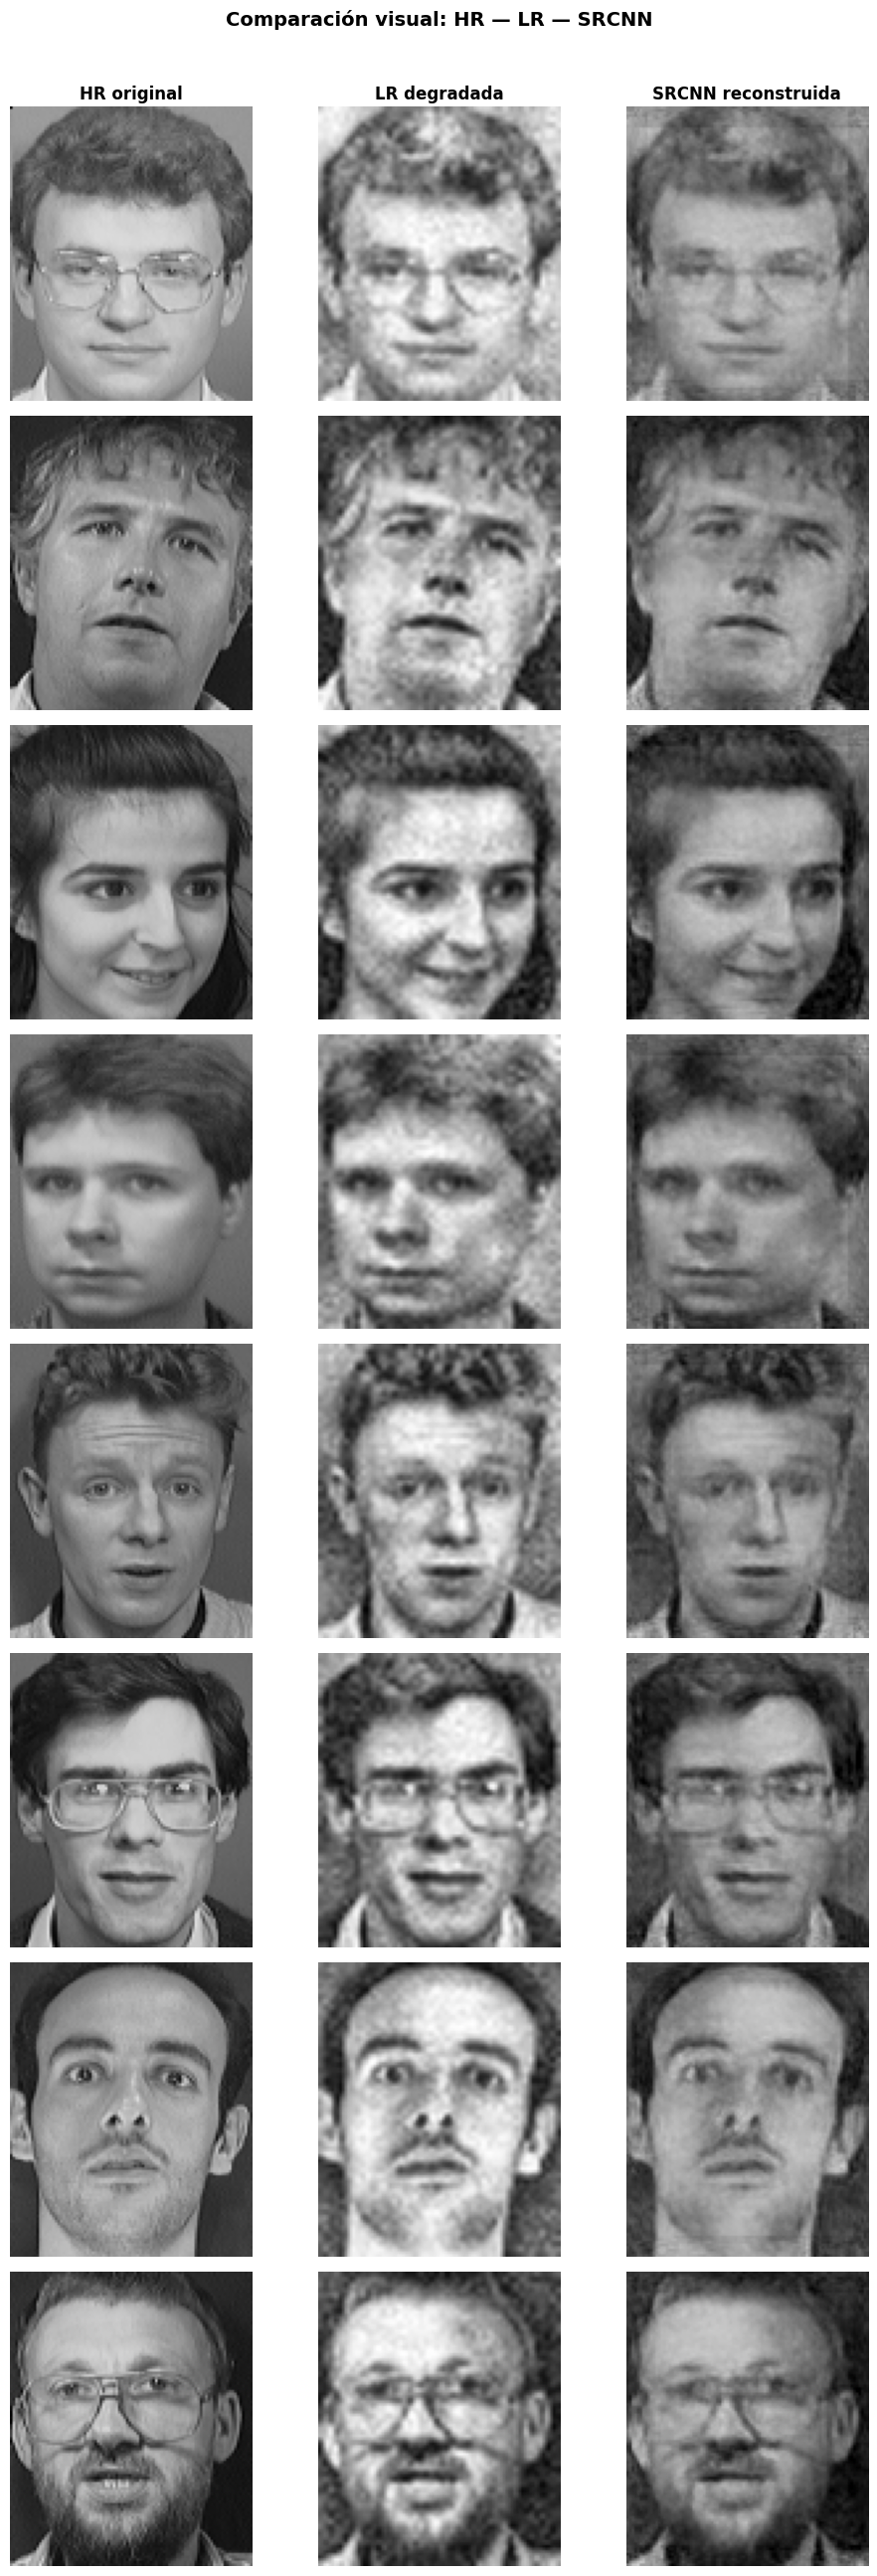

In [ ]:
# ── Cargar pesos guardados ─────────────────────────────────────────────────
checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Pesos cargados desde época {checkpoint["epoch"]}  '
      f'(val_loss={checkpoint["val_loss"]:.6f})')


# ── Función de inferencia sobre una imagen ─────────────────────────────────
@torch.no_grad()
def reconstruct(model, lr_tensor, device):
    """
    lr_tensor: (1, H, W) float32 en [0,1]
    Devuelve: numpy array (H, W) uint8
    """
    inp = lr_tensor.unsqueeze(0).to(device)
    out = model(inp)
    out = torch.clamp(out, 0.0, 1.0)
    return (out.squeeze().cpu().numpy() * 255).astype(np.uint8)


def tensor_to_uint8(t):
    """(1,H,W) float32 → (H,W) uint8"""
    return (t.squeeze().numpy() * 255).astype(np.uint8)


# ── Seleccionar imágenes de prueba (una por sujeto, hasta 8) ───────────────
N_SHOW = 8
test_indices = random.sample(range(len(full_dataset)), min(N_SHOW, len(full_dataset)))

fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3.2 * N_SHOW))
if N_SHOW == 1:
    axes = axes[np.newaxis, :]

col_titles = ['HR original', 'LR degradada', 'SRCNN reconstruida']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, idx in enumerate(test_indices):
    lr_t, hr_t = full_dataset[idx]

    hr_np = tensor_to_uint8(hr_t)
    lr_np = tensor_to_uint8(lr_t)
    sr_np = reconstruct(model, lr_t, DEVICE)

    subject_name = full_dataset.pairs[idx][0].parent.name
    file_name    = full_dataset.pairs[idx][0].stem

    for col, img in enumerate([hr_np, lr_np, sr_np]):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(f'{subject_name}/{file_name}', rotation=90,
                            fontsize=8, labelpad=4)

plt.suptitle('Comparación visual: HR — LR — SRCNN', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluación de metricas 
# Inicializar LPIPS
lpips_fn = lpips.LPIPS(net='vgg').to(DEVICE)
lpips_fn.eval()

#  Evaluación sobre todo el dataset 
eval_loader = DataLoader(full_dataset, batch_size=1, shuffle=False, num_workers=0)

psnr_list_sr,   ssim_list_sr,   lpips_list_sr   = [], [], []
psnr_list_lr,   ssim_list_lr,   lpips_list_lr   = [], [], []

model.eval()

with torch.no_grad():
    for i, (lr_t, hr_t) in enumerate(eval_loader):
        lr_t = lr_t.to(DEVICE)   # (1,1,H,W)
        hr_t = hr_t.to(DEVICE)

        sr_t = torch.clamp(model(lr_t), 0.0, 1.0)

        #  Convertir a numpy uint8 
        hr_np = (hr_t.squeeze().cpu().numpy() * 255).astype(np.uint8)
        lr_np = (lr_t.squeeze().cpu().numpy() * 255).astype(np.uint8)
        sr_np = (sr_t.squeeze().cpu().numpy() * 255).astype(np.uint8)

        # PSNR 
        psnr_sr = psnr_skimage(hr_np, sr_np, data_range=255)
        psnr_lr = psnr_skimage(hr_np, lr_np, data_range=255)
        psnr_list_sr.append(psnr_sr)
        psnr_list_lr.append(psnr_lr)

        # SSIM 
        ssim_sr = ssim_skimage(hr_np, sr_np, data_range=255)
        ssim_lr = ssim_skimage(hr_np, lr_np, data_range=255)
        ssim_list_sr.append(ssim_sr)
        ssim_list_lr.append(ssim_lr)

        # LPIPS (requiere tensor normalizado [-1,1] y 3 canales) 
        def to_lpips_tensor(arr_uint8):
            """uint8 (H,W) → float tensor (1,3,H,W) en [-1,1]"""
            t = torch.from_numpy(arr_uint8).float() / 127.5 - 1.0
            return t.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1).to(DEVICE)

        lp_sr = lpips_fn(to_lpips_tensor(hr_np), to_lpips_tensor(sr_np)).item()
        lp_lr = lpips_fn(to_lpips_tensor(hr_np), to_lpips_tensor(lr_np)).item()
        lpips_list_sr.append(lp_sr)
        lpips_list_lr.append(lp_lr)

        if (i + 1) % 50 == 0:
            print(f'  Procesados {i+1}/{len(eval_loader)} ...')

print('Evaluación completada.')

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth
  Procesados 50/360 ...
  Procesados 100/360 ...
  Procesados 150/360 ...
  Procesados 200/360 ...
  Procesados 250/360 ...
  Procesados 300/360 ...
  Procesados 350/360 ...
Evaluación completada.


In [ ]:
# Métricas promedio 
metrics = {
    'PSNR (dB)' : {'LR baseline' : np.mean(psnr_list_lr),
                   'SRCNN'       : np.mean(psnr_list_sr)},
    'SSIM'      : {'LR baseline' : np.mean(ssim_list_lr),
                   'SRCNN'       : np.mean(ssim_list_sr)},
    'LPIPS ↓'   : {'LR baseline' : np.mean(lpips_list_lr),
                   'SRCNN'       : np.mean(lpips_list_sr)},
}

print('\n' + '═'*52)
print(f'{"Métrica":>12}  {"LR baseline":>14}  {"SRCNN":>12}  {"Δ":>8}')
print('─'*52)
for metric, vals in metrics.items():
    lr_val = vals['LR baseline']
    sr_val = vals['SRCNN']
    delta  = sr_val - lr_val
    sign   = '+' if delta > 0 else ''
    print(f'{metric:>12}  {lr_val:>14.4f}  {sr_val:>12.4f}  {sign}{delta:>7.4f}')
print('═'*52)
print('↓ LPIPS: menor es mejor   |   PSNR/SSIM: mayor es mejor')


════════════════════════════════════════════════════
     Métrica     LR baseline         SRCNN         Δ
────────────────────────────────────────────────────
   PSNR (dB)         16.5413       23.7060  + 7.1647
        SSIM          0.7033        0.7820  + 0.0787
     LPIPS ↓          0.3223        0.2692  -0.0531
════════════════════════════════════════════════════
↓ LPIPS: menor es mejor   |   PSNR/SSIM: mayor es mejor


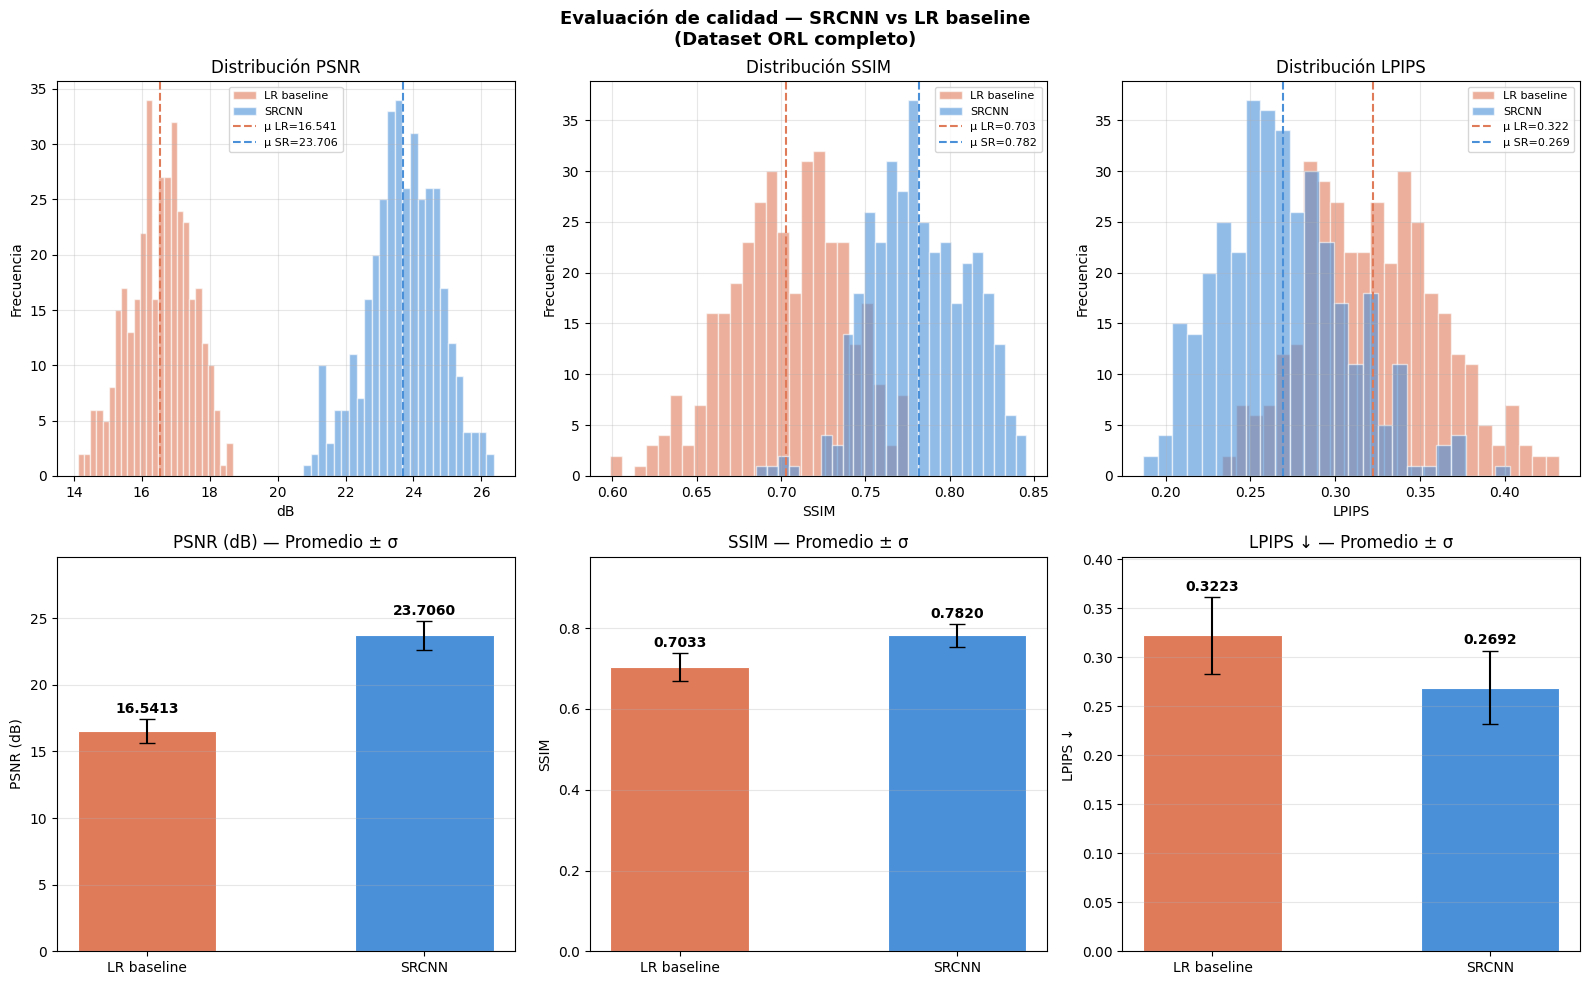

Figura guardada: metrics_evaluation.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Evaluación de calidad — SRCNN vs LR baseline\n(Dataset ORL completo)',
             fontsize=13, fontweight='bold')

colors = {'LR baseline': '#e07b5a', 'SRCNN': '#4a90d9'}
bins   = 25

# Fila 0: histogramas de distribuciones
for col, (title, lr_vals, sr_vals, xlabel) in enumerate([
    ('PSNR', psnr_list_lr, psnr_list_sr, 'dB'),
    ('SSIM', ssim_list_lr, ssim_list_sr, 'SSIM'),
    ('LPIPS', lpips_list_lr, lpips_list_sr, 'LPIPS'),
]):
    ax = axes[0, col]
    ax.hist(lr_vals, bins=bins, alpha=0.6, color=colors['LR baseline'],
            label='LR baseline', edgecolor='white')
    ax.hist(sr_vals, bins=bins, alpha=0.6, color=colors['SRCNN'],
            label='SRCNN', edgecolor='white')
    ax.axvline(np.mean(lr_vals), color=colors['LR baseline'], linestyle='--',
               linewidth=1.5, label=f'μ LR={np.mean(lr_vals):.3f}')
    ax.axvline(np.mean(sr_vals), color=colors['SRCNN'], linestyle='--',
               linewidth=1.5, label=f'μ SR={np.mean(sr_vals):.3f}')
    ax.set_title(f'Distribución {title}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Fila 1: barras de promedios con desviación estándar
metric_data = [
    ('PSNR (dB)', psnr_list_lr, psnr_list_sr),
    ('SSIM',      ssim_list_lr, ssim_list_sr),
    ('LPIPS ↓',   lpips_list_lr, lpips_list_sr),
]

for col, (title, lr_vals, sr_vals) in enumerate(metric_data):
    ax     = axes[1, col]
    means  = [np.mean(lr_vals), np.mean(sr_vals)]
    stds   = [np.std(lr_vals),  np.std(sr_vals)]
    labels = ['LR baseline', 'SRCNN']
    bar_colors = [colors['LR baseline'], colors['SRCNN']]

    bars = ax.bar(labels, means, yerr=stds, capsize=6,
                  color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + s + max(means)*0.01,
                f'{m:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'{title} — Promedio ± σ')
    ax.set_ylabel(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0, max(means) * 1.25)

plt.tight_layout()
plt.savefig('metrics_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: metrics_evaluation.png')

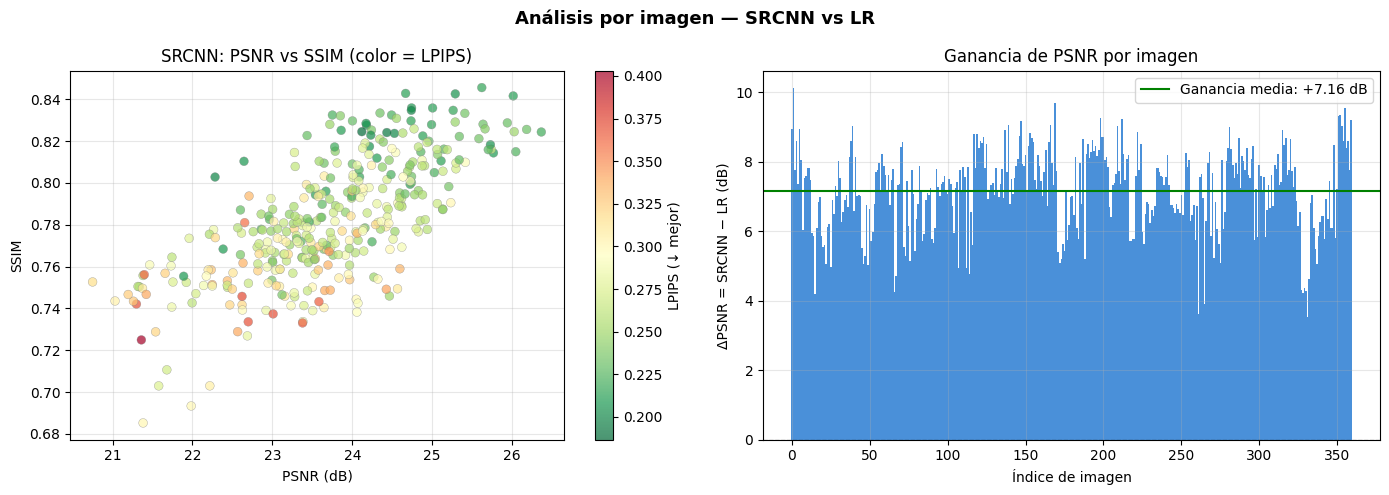

Figura guardada: psnr_gain.png


In [ ]:
# Scatter plot: PSNR vs SSIM coloreado por LPIPS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis por imagen — SRCNN vs LR', fontsize=13, fontweight='bold')

# PSNR vs SSIM 
sc = axes[0].scatter(psnr_list_sr, ssim_list_sr,
                     c=lpips_list_sr, cmap='RdYlGn_r',
                     alpha=0.7, edgecolors='gray', linewidths=0.3, s=40)
axes[0].set_xlabel('PSNR (dB)')
axes[0].set_ylabel('SSIM')
axes[0].set_title('SRCNN: PSNR vs SSIM (color = LPIPS)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[0], label='LPIPS (↓ mejor)')

# Mejora en PSNR: SRCNN - LR
psnr_gain = np.array(psnr_list_sr) - np.array(psnr_list_lr)
n_images  = np.arange(len(psnr_gain))
axes[1].bar(n_images, psnr_gain,
            color=np.where(psnr_gain >= 0, '#4a90d9', '#e07b5a'),
            edgecolor='none', width=1.0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(np.mean(psnr_gain), color='green', linewidth=1.5,
                label=f'Ganancia media: {np.mean(psnr_gain):+.2f} dB')
axes[1].set_xlabel('Índice de imagen')
axes[1].set_ylabel('ΔPSNR = SRCNN − LR (dB)')
axes[1].set_title('Ganancia de PSNR por imagen')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('psnr_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: psnr_gain.png')